<a href="https://colab.research.google.com/github/ramandeepp1403/Customer_Churn_Prediction_Model/blob/main/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [335]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [336]:
df = pd.read_csv('/content/customer_churn.csv')

In [337]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [338]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [339]:
df.describe()



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [340]:
df.isnull().sum()



,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [341]:
df.duplicated().sum()

np.int64(0)

In [388]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

1. Data Manipulation:
*  Extract the 5th column and store it in ‘customer_5’
* Extract the 15th column and store it in ‘customer_15’

In [342]:
customer_5 = df.iloc[:,4]

customer_15 = df.iloc[:,14]

In [343]:
customer_5

,Dependents
0,No
1,No
2,No
3,No
4,No
...,...
7038,Yes
7039,Yes
7040,Yes
7041,No


In [344]:
customer_15

,StreamingMovies
0,No
1,No
2,No
3,No
4,No
...,...
7038,Yes
7039,Yes
7040,No
7041,No


Extract all those customers whose tenure is greater than 70 months or
their monthly charges is more than $100 and store the result in
‘customer_total_tenure’

In [349]:
customer_total_tenure=df[(df['tenure'] > 70) | (df['MonthlyCharges'] > 100)]
customer_total_tenure

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,5604,0,0,1,0,28,1,2,1,0,...,2,2,2,2,0,1,2,104.80,2646,1
12,5751,1,0,1,0,58,1,2,1,0,...,2,0,2,2,1,0,1,100.35,4693,0
13,174,1,0,0,0,49,1,2,1,0,...,2,0,2,2,0,1,0,103.70,4265,1
14,3615,1,0,0,0,25,1,0,1,2,...,2,2,2,2,0,1,2,105.50,2337,0
15,2556,0,0,1,1,69,1,2,1,2,...,2,2,2,2,2,0,1,113.25,5959,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,701,0,1,1,0,63,1,2,1,0,...,2,0,2,2,0,1,2,103.50,5200,0
7034,437,0,0,0,0,67,1,2,1,2,...,2,0,2,0,0,1,1,102.95,5431,1
7037,1758,0,0,0,0,72,1,0,2,1,...,1,1,1,1,2,1,0,21.15,770,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0


Extract all the customers whose contract is of two years, payment method
is mailed check and the value of churn is ‘Yes’ and store the result in
‘two_mail_yes’

In [350]:
two_mail_yes =df[(df['Contract'] == 'Two year') & (df['PaymentMethod'] == 'Mailed check') & (df['Churn'] == 'Yes')]

In [351]:
two_mail_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Extract 333 random records from the customer_churndataframe and store
the result in ‘customer_333’

In [352]:
customer_333 = df.sample(n = 333)
customer_333

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6612,720,1,0,1,1,1,1,0,1,0,...,0,0,0,0,0,1,3,69.90,5454,1
5515,2005,0,0,1,1,18,1,0,2,1,...,1,1,1,1,2,0,3,19.35,2683,0
6455,1700,1,0,1,0,59,0,1,0,0,...,0,0,2,2,0,1,2,44.30,2320,0
5361,1713,0,0,0,1,4,1,0,2,1,...,1,1,1,1,1,1,3,20.40,6177,0
2536,116,1,0,0,0,25,1,2,2,1,...,1,1,1,1,1,0,0,25.30,5352,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4768,2808,1,1,1,1,71,1,0,2,1,...,1,1,1,1,2,0,1,19.80,702,0
4008,510,0,0,1,1,51,0,1,0,0,...,2,2,2,2,1,1,2,56.15,2502,0
254,2571,1,0,0,0,10,1,0,2,1,...,1,1,1,1,0,1,3,19.85,1529,0
4196,4945,0,0,1,1,70,1,2,2,1,...,1,1,1,1,2,0,3,24.05,1290,0


Get the count of different levels from the ‘Churn’ column

In [353]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [354]:
IS_counts=df['InternetService'].value_counts()


In [355]:
IS_counts

,count
InternetService,
1,3096
0,2421
2,1526


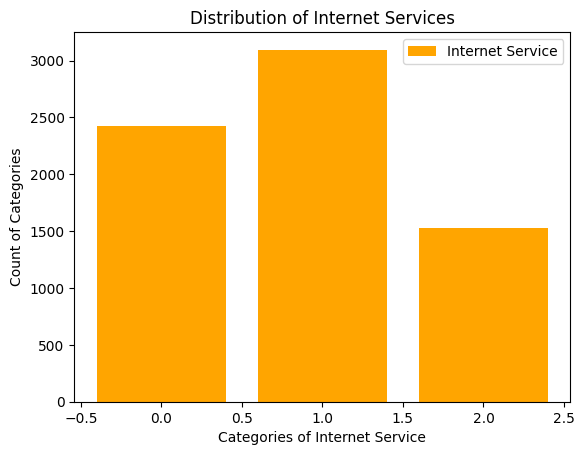

In [356]:
plt.bar(IS_counts.index,IS_counts.values,color = 'orange',label = 'Internet Service')
plt.title("Distribution of Internet Services")
plt.xlabel("Categories of Internet Service")
plt.ylabel("Count of Categories")
plt.legend()
plt.show()

 # Extract all customers who are female, have a contract of Month-to-month, and have churned.

In [357]:
female_monthly_churn = df[(df['gender'] == 'Female') & (df['Contract'] == 'Month-to-month') & (df['Churn'] == 'Yes')]

In [358]:
df['Contract'].value_counts()

,count
Contract,
0,3875
2,1695
1,1473


In [359]:
female_monthly_churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


 # Find the average MonthlyCharges for customers who have Paperless Billing enabled.

In [360]:
avg_monthly_paperless=df[df['PaperlessBilling'] == 'Yes']['MonthlyCharges'].mean()

In [361]:
avg_monthly_paperless

nan

In [362]:
df[df['PaperlessBilling'] == 'Yes']['MonthlyCharges'].mean()

nan

# List the top 5 customers who have the highest TotalCharges.

In [363]:
top_5_total_charges = df.sort_values(by = 'TotalCharges',ascending = False).head(5)

In [364]:
top_5_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2845,6421,0,0,0,0,11,1,0,1,0,...,2,2,0,2,0,1,2,94.20,6530,0
3353,3162,1,0,1,0,12,1,0,1,0,...,0,0,0,2,0,1,1,85.05,6529,0
3686,4173,0,0,0,0,13,1,2,1,0,...,0,0,0,0,0,1,3,75.00,6528,1
5598,4298,0,0,1,1,55,1,0,2,1,...,1,1,1,1,1,0,1,19.15,6527,0
6646,5868,1,0,1,1,51,1,0,2,1,...,1,1,1,1,1,0,3,19.40,6526,0


# Find the total revenue (sum of MonthlyCharges) generated by customers of each Contract type.

In [365]:
df['MonthlyCharges'].dtype

dtype('float64')

In [366]:
# pd.to_numeric , astype(int/float)
df.nlargest(5,'MonthlyCharges')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4586,5360,0,0,1,1,72,1,2,1,2,...,2,2,2,2,2,1,0,118.75,6262,0
2115,6345,0,0,0,0,71,1,2,1,2,...,2,2,2,2,2,1,2,118.65,6201,0
3894,4247,0,0,1,0,68,1,2,1,2,...,2,2,2,2,2,0,3,118.60,6010,0
4804,4067,0,0,0,0,61,1,2,1,2,...,2,2,2,2,1,1,2,118.60,5700,0
5127,5824,1,0,0,0,67,1,2,1,2,...,2,2,2,2,1,1,0,118.35,5921,1


In [367]:
top_5 = df['MonthlyCharges'].nlargest(5)

In [368]:
top_5

,MonthlyCharges
4586,118.75
2115,118.65
3894,118.60
4804,118.60
5127,118.35


In [369]:
total_revenue_contract = df.groupby('Contract')['MonthlyCharges'].sum()

In [370]:
total_revenue_contract

,MonthlyCharges
Contract,
0,257294.15
1,95816.60
2,103005.85


# Plot a histogram of MonthlyCharges with 20 bins, color = purple.

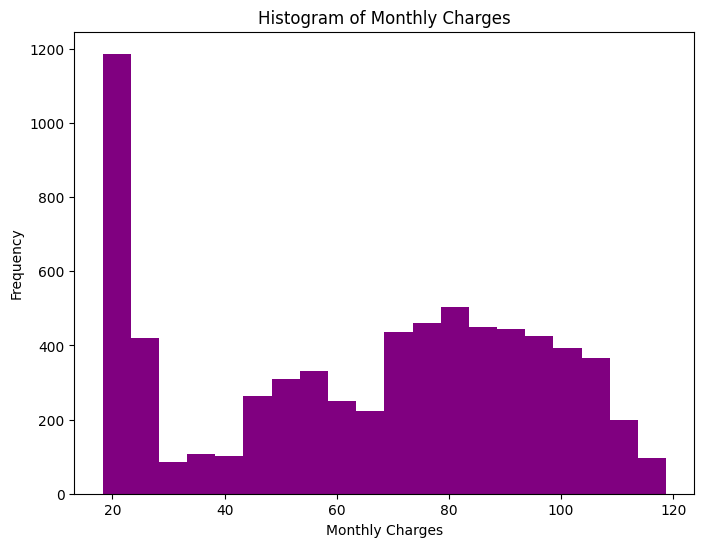

In [371]:
plt.figure(figsize = (8,6))
plt.hist(df['MonthlyCharges'],bins = 20 , color = 'purple')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Histogram of Monthly Charges')
plt.show()

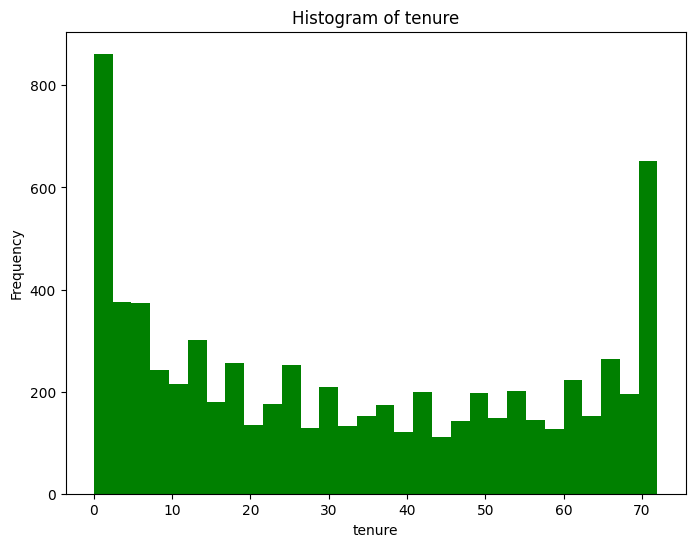

In [372]:
plt.figure(figsize=(8,6))
plt.hist(df['tenure'],bins = 30 , color = 'green')
plt.xlabel('tenure')
plt.ylabel('Frequency')
plt.title('Histogram of tenure')
plt.show()

 Build a scatter plot between MonthlyCharges (y-axis) and tenure (x-axis).
Build a box-plot between tenure (y-axis) and Contract (x-axis)


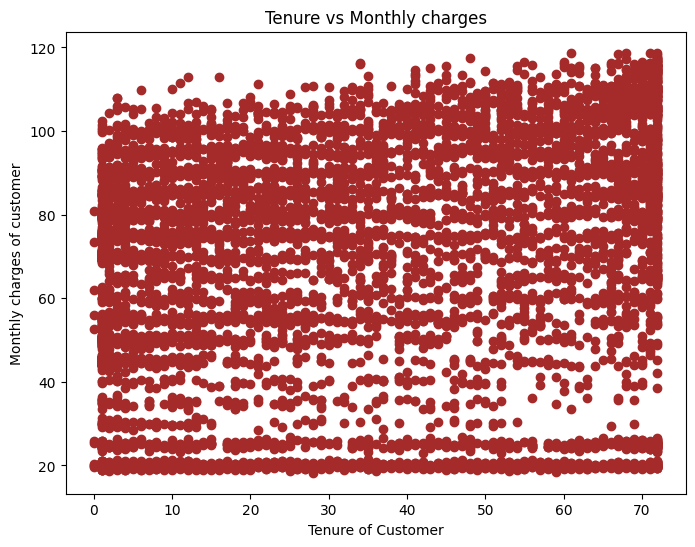

In [373]:
plt.figure(figsize = (8,6))
plt.scatter(df['tenure'],df['MonthlyCharges'],color = 'brown')
plt.xlabel("Tenure of Customer")
plt.ylabel("Monthly charges of customer")
plt.title("Tenure vs Monthly charges")
plt.show()

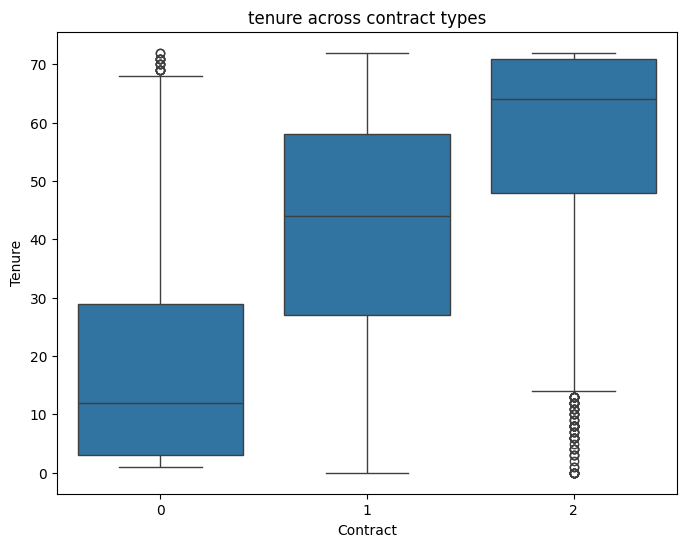

In [374]:
plt.figure(figsize = (8,6))
sns.boxplot(x = df['Contract'],y = df['tenure'],data = df)
plt.xlabel("Contract")
plt.ylabel("Tenure")
plt.title("tenure across contract types")
plt.show()

In [390]:
df= pd.get_dummies(df,drop_first=True)

In [419]:

X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

feature_names = X.columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # Fit only on training data
X_test = scaler.transform(X_test)         # Transform test data

In [395]:
log_reg = LogisticRegression(class_weight='balanced',random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [396]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [397]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [398]:
#pred
log_pred = log_reg.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

In [399]:
models = {
    "Logistic Regression": (log_reg, log_pred),
    "Decision Tree": (dt, dt_pred),
    "Random Forest (Tuned)": (rf, rf_pred)
}

results = []

for name, (model, pred) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:, 1]
        )
    })

comparison = pd.DataFrame(results)

comparison = comparison.round(4)

comparison = comparison.sort_values(by="F1 Score", ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7417,0.5086,0.7888,0.6184,0.8383
2,Random Forest (Tuned),0.7892,0.6314,0.4947,0.5547,0.8230
1,Decision Tree,0.7339,0.4988,0.5348,0.5161,0.6725


In [400]:
grid.fit(X_train,y_train)

rf=grid.best_estimator_

In [401]:
from sklearn.metrics import classification_report

print("========== Logistic Regression ==========")
print(classification_report(y_test, log_pred))

print("========== Decision Tree ==========")
print(classification_report(y_test, dt_pred))

print("========== Random Forest ==========")
print(classification_report(y_test, rf_pred))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

========== Decision Tree ==========
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1035
           1       0.50      0.53      0.52       374

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.67      1409
weighted avg       0.74      0.73      0.74      1409

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg  

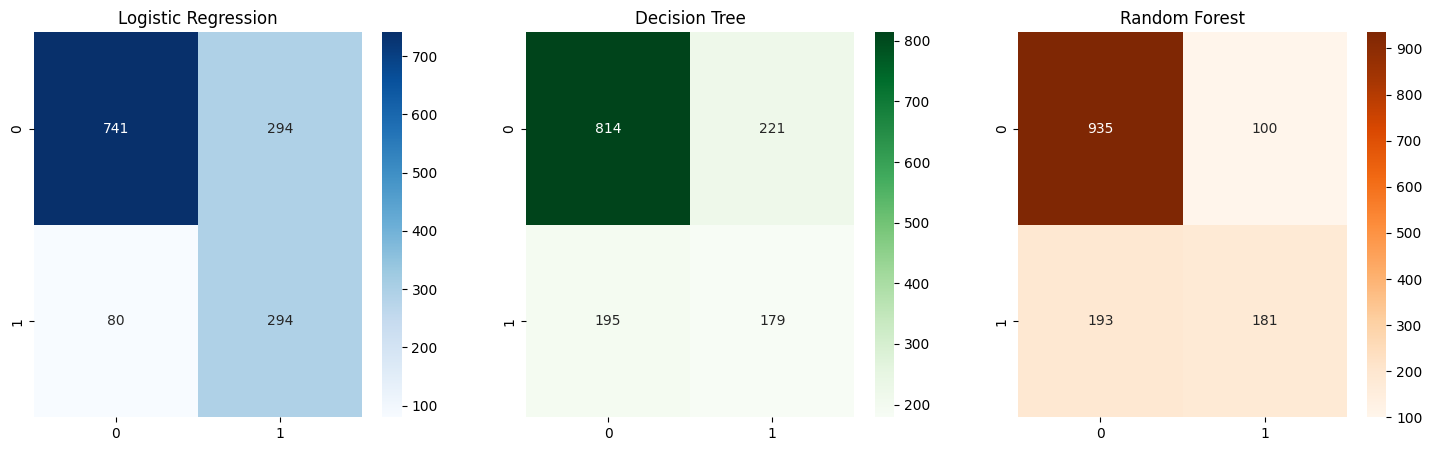

In [382]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")

sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title("Decision Tree")

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)

axes[2].set_title("Random Forest")

plt.show()

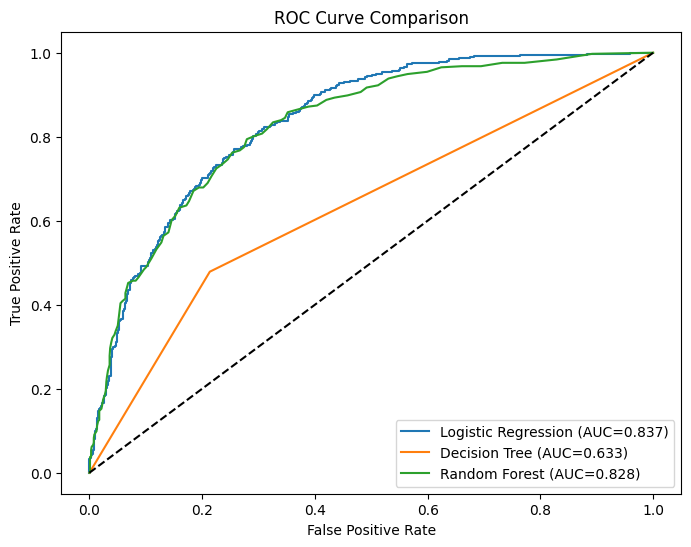

In [383]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

models = [
    ("Logistic Regression", log_reg),
    ("Decision Tree", dt),
    ("Random Forest", rf)
]

for name, model in models:

    prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, prob)

    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [424]:
feature_names = df.drop("Churn", axis=1).columns.tolist()
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


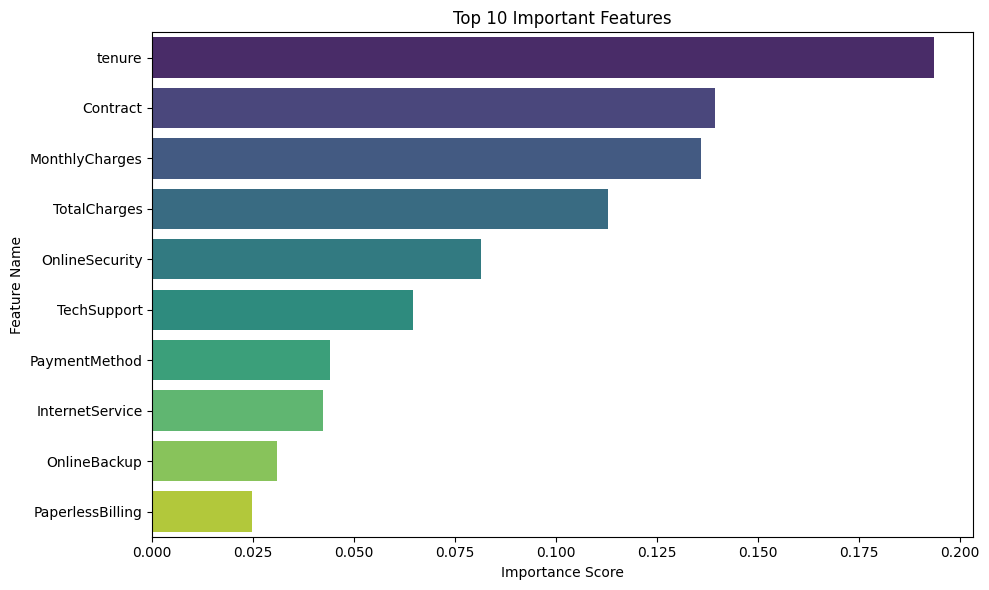

In [425]:
importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.head(10).values,
    y=importance.head(10).index,
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")

plt.tight_layout()
plt.show()

In [426]:
import joblib

joblib.dump(rf,"customer_churn_model.pkl")

joblib.dump(scaler,"scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
